# Lab 3: Image Analysis

In our labs so far, we have been pulling data from Google Earth Engine to visualize in a variety of ways. While visualization is powerful, sometimes we need solid numbers to back up our science. In this event, we need to get zonal statistics.

## Requirements

Everytime you open a new notebook (or your kernel disconnects) you will need to run these requirements before you are able to produce any maps.

The 'pip install' lines are commented out becuase most everyone should already have these libraries installed on your devices, but in case you do not, uncomment and run the first two lines.

In [ ]:
# ! pip install geemap
# ! pip install pygis

import geemap
import ee
from geemap import basemaps

ee.Authenticate()
ee.Initialize(project='Lab3') # Replace 'YOUR_PROJECT_NAME' with the name of your earth engine cloud project

This week, we are introducing some new dependencies. These will help us visualize the statistics we get!

The main one we will focus on is Dr. Qiusheng Wu's [Leafmap](https://leafmap.org/). This is a very powerful python package that can easily integrate geemap data.

In [ ]:
# ! pip install mapclassify
# ! pip install leafmap

import leafmap
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import mapclassify

## Graded Section

This lab is broken into two section:

1. Conceptual - 4 questions (40% total)
2. Challenge - 3 question (60% total)

### Conceptual Questions

10 Points Each

1. Compare the Pennsylvania Sum and Percentage maps. Which counties seem to be most affected by the different stastics used? Why do you think that is?

2. For the Ghana Temperature and Pennsylvania Cultivated Land maps, which statistic do you think best represented the data? Why?

3. For Section 2.1 NDVI we made our date range 1 month, but for 2.2 NDBI we made our date range for a whole year. Why did we do this? Would both images still be reliable if we swapped the date ranges?

4. Interpret the dNDWI image from 2.3 - what do the red and blue areas represent?

### Challenge Questions

#### Challenge 1
Create a choropleth map that includes mean NDVI for counties in a US state *OR*  regions/provinces in a country of your choosing from a single image.

Specific Requirements:
* Make the color scale 'Greens'.
* Use a color map scheme OTHER THAN 'NaturalBreaks'.

Datasets:
* [NDVI](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD13Q1)
* [Counties](https://developers.google.com/earth-engine/datasets/catalog/TIGER_2016_Counties)

Here's an example of a map that would receive full credit:

Screenshot 2024-09-23 at 3.35.28 PM.png

#### Challenge 2
Using TerraClimate data, display the SUM precipitation in a given month for either each county in a state of your choice *OR*  each province/region in a country of your choice.

Specific Requirements:
* Use a color map scheme that you HAVEN'T used yet
* Your color scale should be either ('viridis', 'plasma', 'magma', 'inferno', or 'cividis')

Datasets:
* [Precipitation](https://developers.google.com/earth-engine/datasets/catalog/IDAHO_EPSCOR_TERRACLIMATE)
* [Counties](https://developers.google.com/earth-engine/datasets/catalog/TIGER_2016_Counties)

Here's an example of a map that would receive full credit:

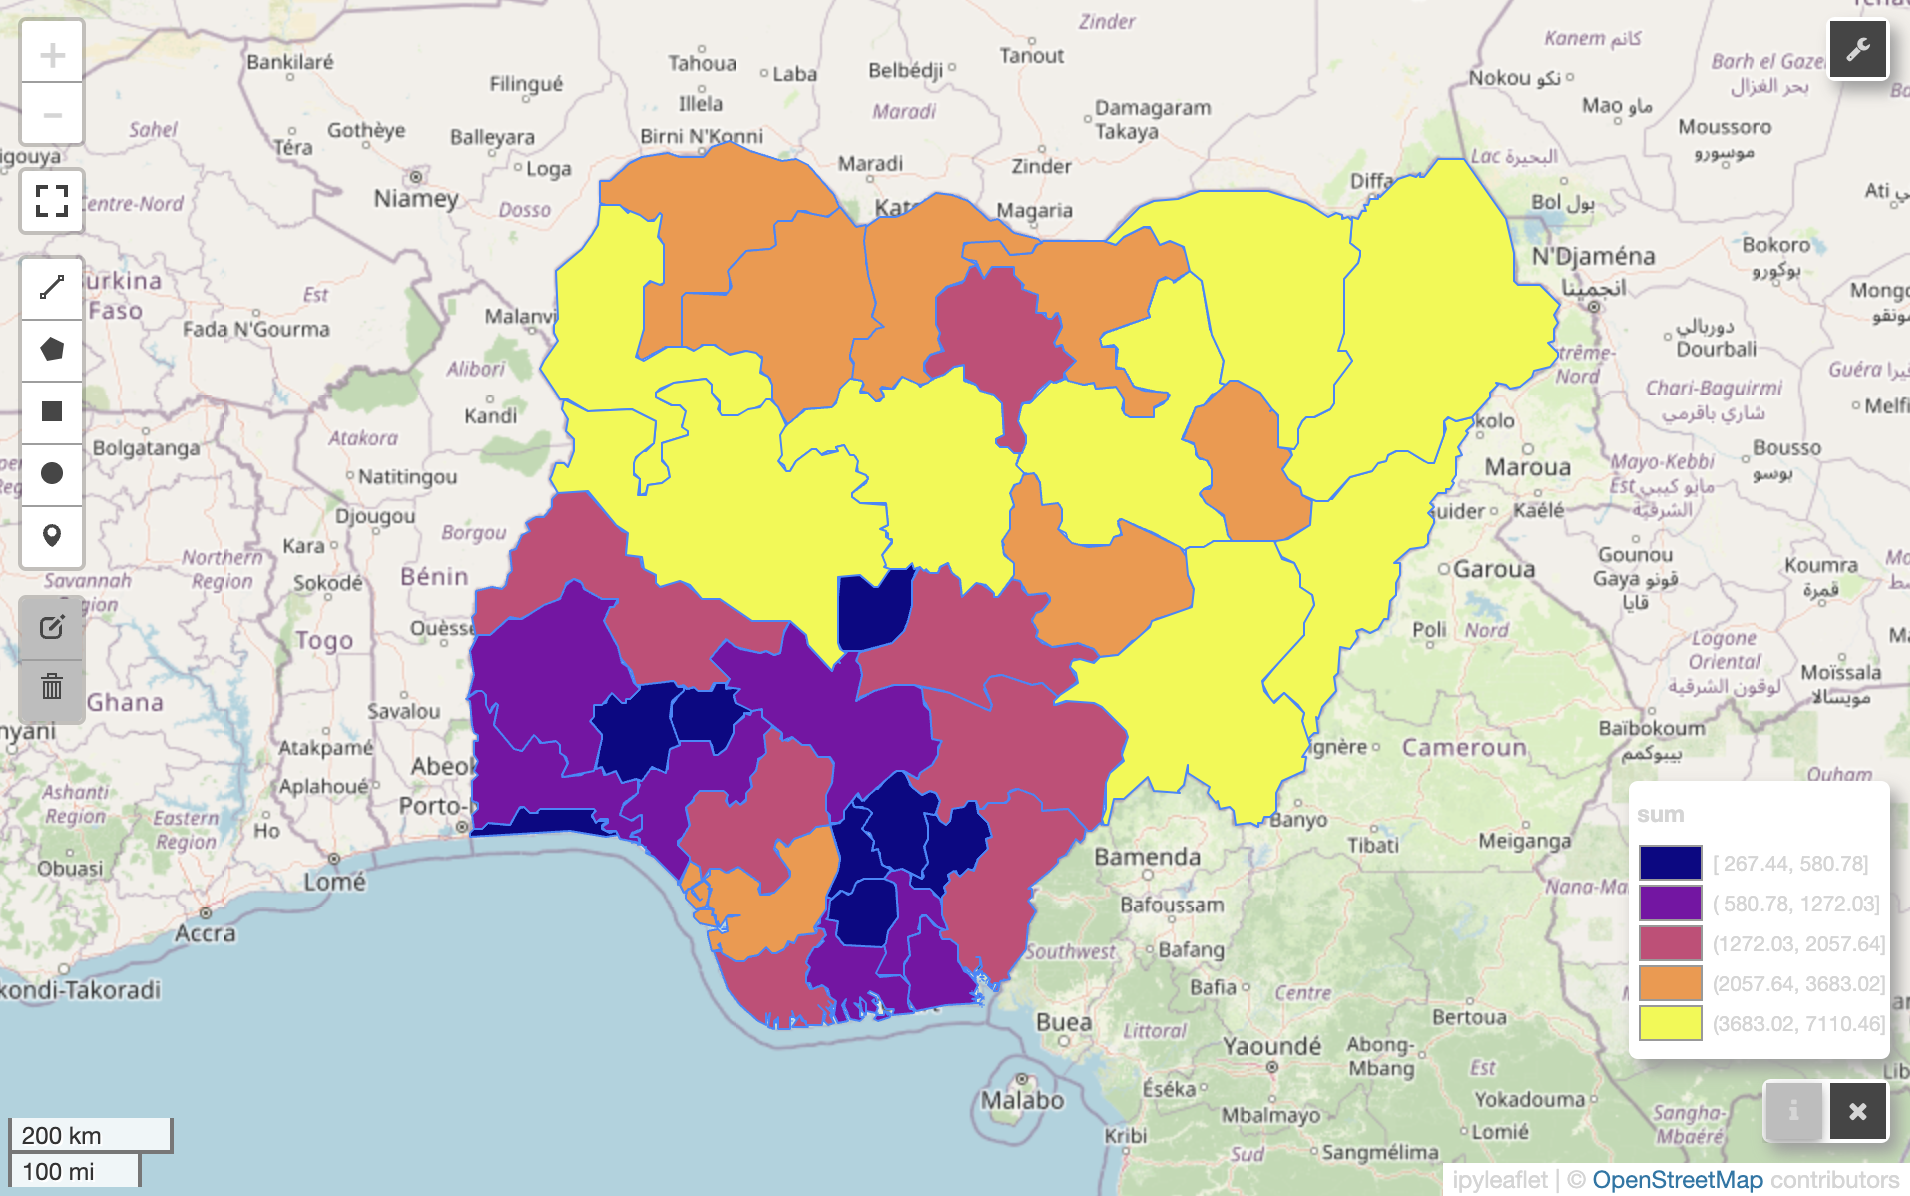

#### Challenge 3
Using the framework from Part 2, conduct change detection in an area of your choosing using any index you desire! (This could be a good opportunity to test ideas for your project.)

Workflow:
1. Define region of interest.
2. Get 2 images, one for each year.
3. Compute index on both images.
4. Calculate difference image.

Hints:

* Use Either [Sentinel-2](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED) or [Landsat](https://developers.google.com/earth-engine/datasets/catalog/landsat) products for your imagery
* Use either [FAO GAUL](https://developers.google.com/earth-engine/datasets/catalog/FAO_GAUL_2015_level0) (Countries) or [TIGER US CENSUS](https://developers.google.com/earth-engine/datasets/catalog/TIGER_2018_States) (United States administrative boundaries) if you want to clip your image to an area. You can also do like 2.1 NDVI and filterBounds by a point.

## Part 1. Spatial Statistics

Sometimes, our project is focused on a specific area and we only need to get information on one band that's stored in an image. To do this, we use the geemap.zonal_stats() function.

### 1.1 Land Surface Temperature

#### 1.1.1 Mean

In [ ]:
# Define the dataset to use (MODIS Land Surface Temperature)
# Filter the image collection to a specific date range (July 2019)
# Select the 'LST_Day' band
lst = ee.ImageCollection("MODIS/061/MOD21C3").filter(ee.Filter.date('2019-07-01', '2019-07-31')).select("LST_Day")

# Define the region of interest (Ghana) from the FAO GAUL dataset
ghana = ee.FeatureCollection("FAO/GAUL/2015/level1").filter(
    ee.Filter.eq('ADM0_NAME', 'Ghana')
    )

In [ ]:
# Define the output location for the zonal statistics CSV file
out_lst_stats = 'lst_mean.csv'

# Run zonal statistics to calculate the mean LST for each region in Ghana
geemap.zonal_stats(
    lst,  # Dataset to calculate statistics from
    ghana,  # Region of interest
    out_lst_stats,  # Output file path
    stat_type='MEAN',   # Statistic type to calculate (Mean)
    scale=1000, # Pixel size in meters (1 km) for calculations
    return_fc=False, # Do not return the feature collection
)

In [ ]:
# Convert the Earth Engine FeatureCollection for Ghana to a GeoDataFrame using geemap
ghana_gdf = geemap.ee_to_gdf(ghana)

# Load the CSV file containing the mean LST data into a pandas DataFrame
csv_path = '/content/lst_mean.csv'  # Replace with your CSV file path
temp_df = pd.read_csv(csv_path)

# Merge the Ghana boundaries GeoDataFrame with the mean LST data based on the 'ADM1_NAME' column
ghana_merged = ghana_gdf.merge(temp_df, on='ADM1_NAME')

# Initialize a leafmap interactive map centered around Ghana with a specified zoom level
mean = leafmap.Map(center=[8, -1], zoom=6)

# Add the merged data to the map to visualize the mean LST as a choropleth map
mean.add_data(ghana_merged,
            column='mean',  # Data column to map (the calculated mean LST)
            cmap='OrRd',  # Color map to use for visualization (Orange to Red)
            scheme='NaturalBreaks',  # Color scheme for classifying data (Natural Breaks)
            )

# Display the map (This will render the interactive map in environments like Jupyter)
mean

#### 1.1.2 Maximum

In [ ]:
# Define the dataset to use (MODIS Land Surface Temperature)
# Filter the image collection to a specific date range (July 1-2, 2019)
# Select the 'LST_Day' band
lst = ee.ImageCollection("MODIS/061/MOD21C3").filter(ee.Filter.date('2019-07-01', '2019-07-02')).select("LST_Day")

# Define the region of interest (Ghana) from the FAO GAUL dataset
ghana = ee.FeatureCollection("FAO/GAUL/2015/level1").filter(
    ee.Filter.eq('ADM0_NAME', 'Ghana')
    )

In [ ]:
# Define output file name for zonal statistics CSV
out_lst_stats = 'lst_max.csv'

# Run zonal statistics to calculate the maximum LST for each region in Ghana
geemap.zonal_stats(
    lst,  # Dataset to calculate statistics from
    ghana,  # Region of interest
    out_lst_stats,  # Output file path
    stat_type='MAXIMUM',   # Statistic type to calculate (Maximum)
    scale=1000, # Pixel size in meters (1 km) for calculations
    return_fc=False , # Do not return the feature collection
)

In [ ]:
# Convert the Earth Engine FeatureCollection for Ghana to a GeoDataFrame using geemap
ghana_gdf = geemap.ee_to_gdf(ghana)

# Load the CSV file containing the maximum LST data into a pandas DataFrame
csv_path = '/content/lst_max.csv'  # Replace with your CSV file path
temp_df = pd.read_csv(csv_path)

# Merge the Ghana boundaries GeoDataFrame with the maximum LST data based on the 'ADM1_NAME' column
ghana_merged = ghana_gdf.merge(temp_df, on='ADM1_NAME')

# Initialize a leafmap interactive map centered around Ghana with a specified zoom level
max = leafmap.Map(center=[8, -1], zoom=6)

# Add the merged data to the map to visualize the maximum LST as a choropleth map
max.add_data(ghana_merged,
            column='max',  # Data column to map (the calculated maximum LST)
            cmap='OrRd',  # Color map to use for visualization (Orange to Red)
            scheme='NaturalBreaks') # Color scheme for classifying data (Natural Breaks)

# Display the map (This will render the interactive map in environments like Jupyter)
max

In [ ]:
# Bring back our mean map to compare
mean

### 1.2 NLCD Landcover

Sometimes, we need the statistics on multiple bands in a dataset. In this case, we must use the geemap.zonal_stats_by_group() function.

Additionally, we can change the color scale and color maps when we visualize in leafmap. Color scale determines how we organize our data in our visualization. Color map is the gradient of colors we choose for our classes.

Here is a link to a list of options for:

 *  [Color map](https://matplotlib.org/3.3.4/tutorials/colors/colormaps.html#sphx-glr-tutorials-colors-colormaps-py)
 *  [Color scale](https://pysal.org/notebooks/viz/mapclassify/intro.html)


The NLCD dataset has a band for each landcover class, so lets get the statistics for each class in our study area!

#### 1.2.1 Sum

The sum function will give us the total number of pixels in our study area for each class. For this example, we will focus on cultivated lands in Pennsylvanian counties.

In [ ]:
# Add NLCD data
dataset = ee.Image('USGS/NLCD_RELEASES/2019_REL/NLCD/2019')
landcover = dataset.select('landcover')  # Select the landcover band

# Add US census states
counties = ee.FeatureCollection("TIGER/2018/Counties")
PA_counties = counties.filter(ee.Filter.eq('STATEFP', '42'))  # Filter for Pennsylvania (STATEFP = 42)

In [ ]:
# Define output directory
nlcd_stats = 'nlcd_sum.csv'

# Run zonal stats
geemap.zonal_stats_by_group(
    landcover,  # Dataset
    PA_counties,  # Region
    nlcd_stats, # Outful file
    stat_type='SUM',  # Stat Type
    denominator=1e6,  # (Optional) data formatting
    decimal_places=2, # (Optional) data formatting
)

In [ ]:
# Convert the EE FeatureCollection to GeoDataFrame using geemap
states_gdf = geemap.ee_to_gdf(PA_counties)

# Load the CSV file with mean elevation data
csv_path = '/content/nlcd_sum.csv'  # Replace with your CSV file path
landcover_df = pd.read_csv(csv_path)

# Merge the China boundaries GeoDataFrame with the CSV elevation data
# Use landcover_df instead of elevation_df
states_merged = states_gdf.merge(landcover_df, on='NAME')

# Initialize the map centered around Pennsylvania
pa_sumEI = leafmap.Map(center=[41, -77], zoom=7)

# Visualize the choropleth directly using explore()
pa_sumEI.add_data(states_merged,
            column='Class_82',  # Data column to map
            cmap='YlOrBr',  # Color map
            scheme='EqualInterval',  # Data scheme
            )

# Display the map (for Jupyter or interactive environments)
pa_sumEI

In [ ]:
# Initialize the map centered around Pennsylvania
pa_sum = leafmap.Map(center=[41, -77], zoom=7)

# Visualize the choropleth directly using add_data()
pa_sum.add_data(states_merged,
            column='Class_82',  # Data column to map
            cmap='YlOrBr',  # Color map
            scheme='NaturalBreaks',  # Data scheme
            )

# Display the map (for Jupyter or interactive environments)
pa_sum

#### 1.2.2 Percentage

The percentage statistic will give us each class in our dataset as a percentage of total pixels for our study area. So, in this example, we will find what percentage of pixels in each county are classified as cultivated lands.

In [ ]:
# Add NLCD data
dataset = ee.Image('USGS/NLCD_RELEASES/2019_REL/NLCD/2019')
landcover = dataset.select('landcover')  # Select the landcover band

# Add US census states
counties = ee.FeatureCollection("TIGER/2018/Counties")
PA_counties = counties.filter(ee.Filter.eq('STATEFP', '42'))  # Filter for Pennsylvania (STATEFP = 42)

In [ ]:
# Define output directory
nlcd_stats = 'nlcd_pct.csv'

# Run zonal stats
geemap.zonal_stats_by_group(
    landcover,  # Dataset
    PA_counties,  # Region
    nlcd_stats, # Outful file
    stat_type='PERCENTAGE', # Stat Type
    denominator=1e6,  # (Optional) data formatting
    decimal_places=2, # (Optional) data formatting
)

In [ ]:
# Convert the EE FeatureCollection to GeoDataFrame using geemap
counties_gdf = geemap.ee_to_gdf(PA_counties)

# Load the CSV file with mean elevation data
csv_path = '/content/nlcd_pct.csv'  # Replace with your CSV file path
landcover_df = pd.read_csv(csv_path)

# Merge the China boundaries GeoDataFrame with the CSV elevation data
# Use landcover_df instead of elevation_df
counties_merged = counties_gdf.merge(landcover_df, on='NAME')

# Initialize the map centered around Pennsylvania
pa_pct = leafmap.Map(center=[41, -77], zoom=7)

# Visualize the choropleth directly using explore()
pa_pct.add_data(counties_merged,
            column='Class_82',  # Data column to map
            cmap='YlOrBr',  # Color map
            scheme='NaturalBreaks',  # Color scale
            )

# Display the map (for Jupyter or interactive environments)
pa_pct

In [ ]:
# Compare our sum map
pa_sum

## Part 2. Temporal Analysis

### 2.1 NDVI

In [ ]:
# Initialize a geemap interactive map with a hybrid basemap
dndvi_map = geemap.Map(basemap='HYBRID')

# Define a point geometry for filtering the image collection
point = ee.Geometry.Point([36.33, 47.93])

# Load the Landsat 8 Collection 2 Tier 1 Level 2 image collection
collection = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(point)

# Define a function to apply scale factors to the image bands
def apply_scale_factors(image):
  # Apply scale factors to optical bands (B2, B3, B4, B5, B6, B7)
  optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
  # Apply scale factors to thermal bands (ST_B10)
  thermal_bands = image.select('ST_B.*').multiply(0.00341802).add(149.0)
  # Add the scaled bands back to the image
  return image.addBands(optical_bands, None, True).addBands(
      thermal_bands, None, True
  )

# Apply the scale factors function to the image collection
collection = collection.map(apply_scale_factors)

# Filter the image collection to get a median image for two different time periods in July, with less than 5% cloud cover
img1 = collection.filter(ee.Filter.date('2021-07-01', '2021-07-31')).filter(
    ee.Filter.lt('CLOUD_COVER', 5)).median()
img2 = collection.filter(ee.Filter.date('2024-07-01', '2024-07-31')).filter(
    ee.Filter.lt('CLOUD_COVER', 5)).median()

# # Define visualization parameters for true color composite
# tcVIS = {
#     'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
#     'min': 0,
#     'max': 0.3,
# }

# # Add true color composite layers to the map
# dndvi_map.addLayer(img1, tcVIS, '2021')
# dndvi_map.addLayer(img2, tcVIS, '2024')

# Calculate NDVI for both images
ndvi1 = img1.normalizedDifference(['SR_B5', 'SR_B4'])
ndvi2 = img2.normalizedDifference(['SR_B5', 'SR_B4'])

# Calculate the difference in NDVI between the two images
dndvi = ndvi2.subtract(ndvi1)

# Define visualization parameters for NDVI and NDVI difference
ndvi_params = {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'green']}
dif_params = {'min': -0.5, 'max': 0.5, 'palette': ['red', 'white', 'green']}

# Add the NDVI and NDVI Difference layers to the map
dndvi_map.addLayer(ndvi1, ndvi_params, 'NDVI 2021')
dndvi_map.addLayer(ndvi2, ndvi_params, 'NDVI 2024')
dndvi_map.addLayer(dndvi, dif_params, 'NDVI Difference')

# Set the center and zoom level of the map
dndvi_map.setCenter(36.4, 47.5, 8)

# Display the map
dndvi_map

### 2.2 NDBI

In [ ]:
# Initialize a geemap interactive map with a hybrid basemap
ndwi_map = geemap.Map(basemap='HYBRID')

# Set the center and zoom level of the map to focus on Davidson County
ndwi_map.setCenter(-86.75, 36.1, 10)

# Display the map
ndwi_map

In [ ]:
## PART 1: ROI
# Define the region of interest (Davidson County, TN) from the TIGER/2018/Counties dataset
counties = ee.FeatureCollection("TIGER/2018/Counties")
tn_counties = counties.filter(ee.Filter.eq('STATEFP', '47')) # Filter for Tennessee (STATEFP = 47)
davidson = tn_counties.filter(ee.Filter.eq('NAME', 'Davidson')) # Filter for Davidson County

# Load Landsat 7 and Landsat 8 Collection 2 Tier 1 Level 2 image collections
l7 = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2")

# Apply scale factors to both image collections using the previously defined function
l7 = l7.map(apply_scale_factors)

# Filter the image collections to get a median image for two different time periods (2001 and 2021)
# Filter for images with less than 5% cloud cover and clip to the Davidson County boundary
img1 = l7.filter(ee.Filter.date('2001-01-01', '2001-12-31')).filter(
    ee.Filter.lt('CLOUD_COVER', 5)).median().clip(davidson)
img2 = l7.filter(ee.Filter.date('2019-01-01', '2019-12-31')).filter(
    ee.Filter.lt('CLOUD_COVER', 5)).median().clip(davidson)

# # Define visualization parameters for true color composite (Landsat 7 bands)
# tcVIS = {
#     'bands': ['SR_B3', 'SR_B2', 'SR_B1'],
#     'min': 0,
#     'max': 0.3,
# }

# # Add true color composite layers to the map
# ndwi_map.addLayer(img1, tcVIS, '2001')
# ndwi_map.addLayer(img2, tcVIS, '2019')

# Calculate NDBI (Normalized Difference Built-up Index) for both images
# NDBI for Landsat 7 uses bands SR_B5 (SWIR) and SR_B4 (NIR)
# NDBI for Landsat 8 uses bands SR_B6 (SWIR) and SR_B5 (NIR)
ndbi1 = img1.normalizedDifference(['SR_B5', 'SR_B4'])
ndbi2 = img2.normalizedDifference(['SR_B5', 'SR_B4'])

# Calculate dNDBI
dndbi = ndbi2.subtract(ndbi1)

# Define visualization parameters for NDBI
ndbi_params = {'min': -1, 'max': 1, 'palette': ['blue', 'white', 'red']}
dndbi_params = {'min': -0.5, 'max': 0.5, 'palette': ['blue', 'white', 'red']}

# Add the NDBI layers to the map
ndwi_map.addLayer(ndbi1, ndbi_params, 'NDBI 2001')
ndwi_map.addLayer(ndbi2, ndbi_params, 'NDBI 2019')
ndwi_map.addLayer(dndbi, dndbi_params, 'dNDBI')

### 2.3 NDWI

In [ ]:
# Initialize a geemap interactive map with a hybrid basemap
ndwi_map = geemap.Map(basemap='HYBRID')

# Define the region of interest (Bangladesh) from the FAO GAUL dataset
bangladesh = ee.FeatureCollection("FAO/GAUL/2015/level0").filter(
    ee.Filter.eq('ADM0_NAME', 'Bangladesh')
    )

# Load Landsat 8 Collection 2 Tier 1 Level 2 image collection
l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")

# Apply scale factors to the image collection using the previously defined function
l8 = l8.map(apply_scale_factors)

# Filter the image collection to get a median image for two different time periods (2014 and 2024) during the dry season (March-May)
# Filter for images with less than 5% cloud cover and clip to the Bangladesh boundary
img1 = l8.filter(ee.Filter.date('2014-03-01', '2014-05-31')).filter(
    ee.Filter.lt('CLOUD_COVER', 5)).median().clipToCollection(bangladesh)
img2 = l8.filter(ee.Filter.date('2024-03-01', '2024-05-31')).filter(
    ee.Filter.lt('CLOUD_COVER', 5)).median().clipToCollection(bangladesh)

# Define visualization parameters for true color composite
tcVIS = {
    'bands': ['SR_B4', 'SR_B3', 'SR_B2'],
    'min': 0,
    'max': 0.3,
}

# Add true color composite layers to the map
ndwi_map.addLayer(img1, tcVIS, '2014')
ndwi_map.addLayer(img2, tcVIS, '2024')

# Calculate ndwi (Normalized Difference Moisture Index) for both images
# ndwi uses bands SR_B3 (Green) and SR_B5 (SWIR) for Landsat 8
ndwi1 = img1.normalizedDifference(['SR_B3', 'SR_B5'])
ndwi2 = img2.normalizedDifference(['SR_B3', 'SR_B5'])

# Calculate the difference in ndwi between the two images
dndwi = ndwi2.subtract(ndwi1)

# Define visualization parameters for ndwi and ndwi difference
ndwi_vis = {'min': -1, 'max': 1, 'palette': ['red', 'white', 'blue']}
dif_params = {'min': -0.5, 'max': 0.5, 'palette': ['red', 'white', 'blue']}

# Add ndwi and ndwi Difference layers to the map
ndwi_map.addLayer(ndwi1, ndwi_vis, 'ndwi 2014')
ndwi_map.addLayer(ndwi2, ndwi_vis, 'ndwi 2024')
ndwi_map.addLayer(dndwi, dif_params, 'ndwi Difference')

# Set the center and zoom level of the map to focus on Bangladesh
ndwi_map.setCenter(90, 24, 6)

# Display the map
ndwi_map

## (EXTRA) Timeseries Zonal Statistics

This section is an advanced example. You will not need this for your challenge questions. You will, however, be asked to interpret the graph in your last Conceptual Question.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ndvi = ee.ImageCollection("MODIS/061/MOD13Q1").filter(
    ee.Filter.date('2020-01-01', '2020-12-31'))
states = ee.FeatureCollection("TIGER/2018/States")
wv = states.filter(ee.Filter.eq('STUSPS', 'WV'))

In [ ]:
# Directory where CSV files will be saved
output_dir = "ndvi_stats"  # Change to the directory where you want to save the CSV files
os.makedirs(output_dir, exist_ok=True)  # Create the directory if it doesn't exist

# Loop through each feature (image) to calculate zonal statistics
for feat in ndvi.getInfo()['features']:
    image = ee.Image(feat['id'])  # Extract the image from the feature dictionary using its ID

    # Get the image date from its properties to use it in the filename
    image_date = ee.Date(feat['properties']['system:time_start']).format('YYYY-MM-dd').getInfo()

    # Generate a unique filename for each CSV
    out_ndvi_stats = os.path.join(output_dir, f'ndvi_mean_{image_date}.csv')

    # Perform zonal statistics and save the results to CSV
    geemap.zonal_stats(
        image,
        wv,  # The region of interest (ROI)
        out_ndvi_stats,  # Output CSV file path
        statistics_type='MEAN',
        scale=500
    )

    print(f"Saved NDVI statistics for {image_date} to {out_ndvi_stats}")

In [ ]:
# List all CSV files in the directory
csv_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.csv')]

# Initialize an empty list to store individual dataframes
dataframes = []

# Loop through the CSV files and read each into a dataframe
for csv_file in csv_files:
    # Read the CSV file
    df = pd.read_csv(csv_file)

    # Extract the date from the filename
    date_str = os.path.basename(csv_file).replace('ndvi_mean_', '').replace('.csv', '')

    # Add a 'date' column to the dataframe
    df['date'] = date_str

    # Append the dataframe to the list
    dataframes.append(df)

# Combine all the individual dataframes into a single dataframe
combined_df = pd.concat(dataframes, ignore_index=True)

# Convert the 'date' column to a datetime object for easier plotting
combined_df['date'] = pd.to_datetime(combined_df['date'])

# Sort the dataframe by date
combined_df = combined_df.sort_values('date')

# Divide 'NDVI' Values by 1000
combined_df['NDVI'] = combined_df['NDVI'] / 100

# Plot the time series of NDVI values using Seaborn or Matplotlib
plt.figure(figsize=(10, 6))
sns.lineplot(data=combined_df, x='date', y='NDVI', marker='o')  # Use 'NDVI' for y-axis

# Customize the plot
plt.title('NDVI Mean Time Series')
plt.xlabel('Date')
plt.ylabel('Mean NDVI %')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()